In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
filename = 'output/flowVolume.csv'

# 读取CSV文件
data = pd.read_csv(filename)

# 提取时间和流量数据
time = data['time'].values # 0-23
flow_volume = data['flow volume'].values # 0-23小时对应的流量

# 在flow_volume后面加上12个0，表示24-35小时的流量为0
flow_trend = np.concatenate((flow_volume, np.zeros(12)))

data.head()

,time,flow volume
0,0,1.2
1,1,1.0
2,2,0.8
3,3,0.6
4,4,0.4


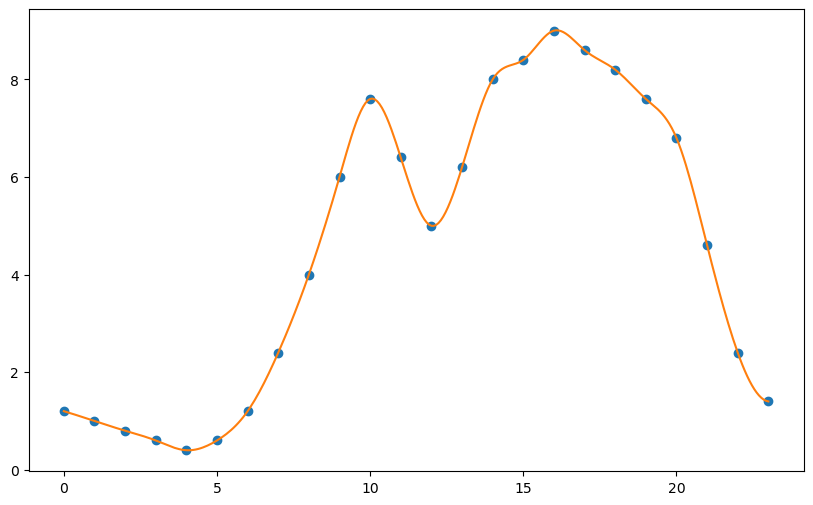

In [3]:
# 创建插值函数，用于生成光滑曲线
f = interp1d(time, flow_volume, kind='cubic', fill_value="extrapolate")

# 创建用于绘图的更密集的时间点
dense_time = np.linspace(time[0], time[-1], 300)

# 使用插值函数计算密集时间点的流量
dense_flow_volume = f(dense_time)

# 绘制原始数据点
plt.figure(figsize=(10, 6))
plt.plot(time, flow_volume, 'o', label='Original Data')

# 绘制拟合曲线
plt.plot(dense_time, dense_flow_volume, '-', label='Smooth Curve')

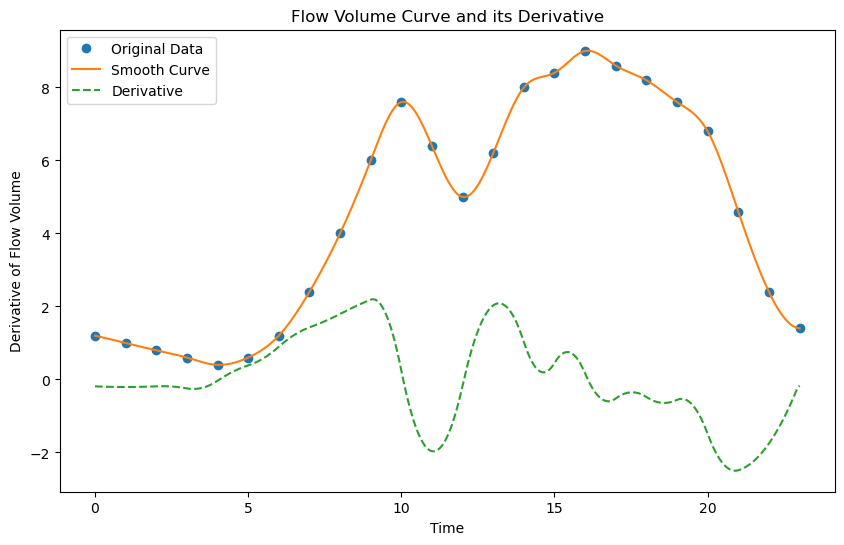

In [4]:
# 计算时间点之间的平均间距
time_spacing = np.mean(np.diff(dense_time))

# 使用np.gradient来计算导数，这里我们计算的是流量相对于时间的变化率
derivative = np.gradient(dense_flow_volume, time_spacing)

# 绘制原始数据点
plt.figure(figsize=(10, 6))
plt.plot(time, flow_volume, 'o', label='Original Data')

# 绘制拟合曲线
plt.plot(dense_time, dense_flow_volume, '-', label='Smooth Curve')

# 绘制导数曲线
plt.plot(dense_time, derivative, '--', label='Derivative')

# 添加图例和标签
plt.legend()
plt.xlabel('Time')
plt.ylabel('Derivative of Flow Volume')
plt.title('Flow Volume Curve and its Derivative')

# 显示图表
plt.show()

In [5]:
for i in range(len(dense_time)):
    print(dense_time[i],derivative[i])

0.0 -0.18873514423138227
0.07692307692307693 -0.19008692692361417
0.15384615384615385 -0.19267784375039765
0.23076923076923078 -0.19504346346181034
0.3076923076923077 -0.19718378605784792
0.38461538461538464 -0.19909881153851328
0.46153846153846156 -0.20078853990380208
0.5384615384615385 -0.2022529711537201
0.6153846153846154 -0.20349210528827166
0.6923076923076923 -0.20450594230744668
0.7692307692307693 -0.20529448221124946
0.8461538461538463 -0.2058577249996829
0.9230769230769231 -0.2061956706727398
1.0 -0.2063083192304252
1.076923076923077 -0.20619567067273908
1.153846153846154 -0.20585772499968147
1.2307692307692308 -0.20529448221124946
1.3076923076923077 -0.20450594230744595
1.3846153846153846 -0.20349210528827383
1.4615384615384617 -0.20225297115372298
1.5384615384615385 -0.20078853990380136
1.6153846153846154 -0.1990988115385111
1.6923076923076925 -0.19718378605784648
1.7692307692307694 -0.19504346346180818
1.8461538461538463 -0.19267784375039837
1.9230769230769231 -0.1900869269

In [6]:
import json
import pandas as pd
import numpy as np
# 从文件读取
with open('output/data_13e.json', 'r') as f:
    path_data = json.load(f)
# print(path_data)
dist = pd.read_csv('output/dist_13e.csv',header=0,index_col=0)
dist = dist.map(np.abs) # 取距离的绝对值

weight = pd.read_csv('output/population_13e.csv',header=0,index_col=None) #每个出入口对应的城市人口
print(weight)

     e1   e2   e3   e4   e5   e6    e7    e8   e9  e10  e11  e12   e13
0  2183  547  723  549  944  944  1085  1085  452  458  458  447  2487


In [7]:
# 计算每个OD对的交互作用，目的是为了计算每个OD对的需求量权重

interaction = {}


for p in path_data: # 遍历每个OD对
    # Ensure all inputs are scalars
    source_weight = weight[path_data[p]['source']].values[0]  # 提取每个od对的源城市人口，作为需求源权重
    root_weight = weight[path_data[p]['root']].values[0]  # 提取每个od对的汇城市人口，作为需求汇权重
    distance = dist[path_data[p]['source']][path_data[p]['root']]  # 提取每个od对的距离，作为需求距离

    # Print scalar values
    print(source_weight, root_weight, distance)

    # Calculate interaction and assign it as a scalar value
    interaction[p] = source_weight * root_weight / distance**2
    
    # Print the scalar value of interaction for each path
    print(interaction[p])

2183 549 279.0
15.396346398427564
2183 944 340.0
17.826574394463666
2183 944 440.0
10.644380165289256
2183 1085 507.0
9.21441048204817
2183 1085 634.0
5.892572818915503
2183 452 750.0
1.7541617777777778
2183 458 822.0
1.479706490016043
2183 458 887.0
1.2707846902966435
2183 447 995.0
0.9856326860432817
2183 2487 1140.0
4.177532317636196
547 944 246.0
8.532751668980104
547 944 346.0
4.31327475024224
547 1085 413.0
3.4795009644190915
547 1085 540.0
2.0353052126200275
547 452 656.0
0.5745371058893516
547 458 728.0
0.4727048363724188
547 458 793.0
0.3983881663165561
547 447 901.0
0.30119327273555957
547 2487 1046.0
1.2433681620595989
723 944 263.0
9.867310500368662
723 1085 330.0
7.2034435261707985
723 1085 457.0
3.756086933621899
723 452 573.0
0.9953309028444031
723 458 645.0
0.7959473589327565
723 458 710.0
0.6568815711168419
723 447 818.0
0.48299119445723065
723 2487 963.0
1.9389272231441854
549 2183 279.0
15.396346398427564
549 1085 228.0
11.45862188365651
549 1085 355.0
4.726562190041

In [8]:
import random
import numpy as np
import json
# distribute total flow
fS = {} #短续航流量
fL = {} #长续航流量
#Low
# flow_trend = [0.05, 0.05, 0.05, 0.05, 0.05, 0.3, 0.5, 0.6, 0.7, 0.8, 0.6, 0.5, 0.6, 0.8, 0.7, 0.6, 0.5, 0.3, 0.3, 0.3, 0.1, 0.05, 0.05, 0.05,0,0,0,0,0,0,0,0,0,0,0,0]
#Mid
#flow_trend = [0.05,0.05,0.05,0.05,0.05,0.4,1,1.5,2,2.5,1.5,1,1.5,2.5,2,1.5,1,0.5,0.5,0.5,0.1,0.05,0.05,0.05,0,0,0,0,0,0,0,0,0,0,0,0]
#High
#flow_trend = [0.5, 0.5, 0.5, 0.7, 1, 2.5, 2.8, 3.2, 3.5, 3.7, 3.3, 3, 3.2, 3.8, 3.5, 3.2, 3, 2.5, 2.5, 2.3, 1.5, 0.7, 0.5, 0.5,0,0,0,0,0,0,0,0,0,0,0,0]




num_scenario = 160   # Number of scenarios to generate
ratio = 0.6         # 0.6 means 60% of the flow goes to fS and 40% goes to fL


# Normalize flow trend to obtain probabilities 按时间归一化
probabilities = [flow / sum(flow_trend) for flow in flow_trend]

# Assume interaction is predefined, sum_interaction represents the total sum of all interactions
sum_interaction = sum(interaction.values())

# Precompute base flows for fL, as they should remain constant across scenarios
fS_base = {}
fL_base = {}
fS_pt = {}
fL_pt = {}

# Compute fL_pt for each path (base flow) only once
for p in path_data:  
    # 每个OD对的流量分配比例根据交互作用进行分配的比例，在这里就是每个O-D的流量占总流量的比例
    fS_base[p] = ratio * interaction[p] / sum_interaction
    fL_base[p] = (1 - ratio) *  interaction[p] / sum_interaction

    # Distribute flows across time periods
    for t in range(len(probabilities)):
        # Calculate flow for each time period based on binomial distribution
        #print(fS_base[p],probabilities[t])
        fS_pt[p,t] = fS_base[p]*probabilities[t]
        fL_pt[p,t] = fL_base[p]*probabilities[t]
        #print(fS_pt[p,t])

#print((sum(fS_pt.values())+sum(fL_pt.values()))*num_scenario)
# sum(fS_pt.values())
# 在流量计算前添加检查
total_fS_pt = sum(fS_pt.values())
total_fL_pt = sum(fL_pt.values())
print(f"Total fS_pt: {total_fS_pt}")
print(f"Total fL_pt: {total_fL_pt}")
print(f"Total combined: {total_fS_pt + total_fL_pt}")


Total fS_pt: 0.6000000000000026
Total fL_pt: 0.3999999999999997
Total combined: 1.0000000000000022


In [9]:
sigma_ratio = 0.3  # cv
total_volume = 300 # 8e的是200，13e的是300
np.random.seed(1)

fS = {}
fL = {}

# 每个场景内分别保证短续航和长续航总量，再合并
total_S = int(round(total_volume * ratio))
total_L = total_volume - total_S

for i in range(num_scenario):
    # 为当前场景生成扰动后的权重（非负）
    weights_S = []
    weights_L = []
    index_list = []  # 保存 (p, t) 映射
    
    for p in path_data:
        for t in range(24):
            eps_S = np.random.normal(0, sigma_ratio) * fS_pt[p, t]
            eps_L = np.random.normal(0, sigma_ratio) * fL_pt[p, t]
            val_S = max(0.0, fS_pt[p, t] + eps_S)
            val_L = max(0.0, fL_pt[p, t] + eps_L)
            weights_S.append(val_S)
            weights_L.append(val_L)
            index_list.append((p, t))

    weights_S = np.array(weights_S, dtype=float)
    weights_L = np.array(weights_L, dtype=float)

    # 归一化为概率；极端情况下退化为均匀分布
    if weights_S.sum() <= 0:
        prob_S = np.full_like(weights_S, 1.0 / len(weights_S))
    else:
        prob_S = weights_S / weights_S.sum()

    if weights_L.sum() <= 0:
        prob_L = np.full_like(weights_L, 1.0 / len(weights_L))
    else:
        prob_L = weights_L / weights_L.sum()

    # 一次性整数分配，保证总量守恒
    alloc_S = np.random.multinomial(total_S, prob_S)
    alloc_L = np.random.multinomial(total_L, prob_L)

    for idx, (p, t) in enumerate(index_list):
        fS[i, p, t] = int(alloc_S[idx])
        fL[i, p, t] = int(alloc_L[idx])

    # 24-35 时段保持 0
    for p in path_data:
        for t in range(24, 36):
            fS[i, p, t] = 0
            fL[i, p, t] = 0

    scenario_total = sum(v for k, v in fS.items() if k[0] == i) + sum(v for k, v in fL.items() if k[0] == i)
    print(f"scenario {i}: total={scenario_total}, S={sum(v for k, v in fS.items() if k[0] == i)}, L={sum(v for k, v in fL.items() if k[0] == i)}")

print((sum(fS.values()) + sum(fL.values())) / num_scenario)

scenario 0: total=300, S=180, L=120
scenario 1: total=300, S=180, L=120
scenario 2: total=300, S=180, L=120
scenario 3: total=300, S=180, L=120
scenario 4: total=300, S=180, L=120
scenario 5: total=300, S=180, L=120
scenario 6: total=300, S=180, L=120
scenario 7: total=300, S=180, L=120
scenario 8: total=300, S=180, L=120
scenario 9: total=300, S=180, L=120
scenario 10: total=300, S=180, L=120
scenario 11: total=300, S=180, L=120
scenario 12: total=300, S=180, L=120
scenario 13: total=300, S=180, L=120
scenario 14: total=300, S=180, L=120
scenario 15: total=300, S=180, L=120
scenario 16: total=300, S=180, L=120
scenario 17: total=300, S=180, L=120
scenario 18: total=300, S=180, L=120
scenario 19: total=300, S=180, L=120
scenario 20: total=300, S=180, L=120
scenario 21: total=300, S=180, L=120
scenario 22: total=300, S=180, L=120
scenario 23: total=300, S=180, L=120
scenario 24: total=300, S=180, L=120
scenario 25: total=300, S=180, L=120
scenario 26: total=300, S=180, L=120
scenario 27

In [10]:
# Convert to JSON format and save the results
json_data_fS = {str(k): v for k, v in fS.items()}
json_data_fL = {str(k): v for k, v in fL.items()}

with open(f'13e_flow_S_{total_volume}_{sigma_ratio:.2f}.json', 'w') as f:
    json.dump(json_data_fS, f)

with open(f'13e_flow_L_{total_volume}_{sigma_ratio:.2f}.json', 'w') as f:
    json.dump(json_data_fL, f)

In [ ]:
def generate_flow_data(Q, P, num_scenarios, target_variance):
    T = len(P)
    flows = []

    for _ in range(num_scenarios):
        # 计算每个时间段的期望流量
        expected_flow = Q * P

        # 使用正态分布生成流量，控制方差
        flow_distribution = np.random.normal(loc=expected_flow, scale=np.sqrt(target_variance), size=T)

        # 确保生成的流量为非负整数
        flow_distribution = np.maximum(np.round(flow_distribution).astype(int), 0)

        # 归一化，使总流量等于 Q
        total_flow = flow_distribution.sum()
        if total_flow > 0:
            flow_distribution = np.round(flow_distribution * (Q / total_flow)).astype(int)

        flows.append(flow_distribution)

    return np.array(flows)

# 示例参数
Q = 10  # 总流量
P = [0.1, 0.2, 0.7]  # 概率分布
num_scenarios = 5  # 场景数量
target_variance = 2  # 目标方差

flow_data = generate_flow_data(Q, P, num_scenarios, target_variance)
print(flow_data)


291
602
892
1197
1509
1802
2097
2397
2714
2996
3291
3600
3890
4197
4496
4799
5106
5412
5714
6019
6328
6626
6929
7250
7567
7885
8207
8515
8836
9134
9421
9709
10037
10331
10638
10939
11237
11569
11876
12169
12462
12760
13077
13399
13704
13998
14317
14619
14921
15212


In [ ]:
import random
import numpy as np
import json
# distribute total flow
fS = {} #短续航路径流量
fL = {} #长续航路径流量
#Low
#flow_trend = [0.05, 0.05, 0.05, 0.05, 0.05, 0.3, 0.5, 0.6, 0.7, 0.8, 0.6, 0.5, 0.6, 0.8, 0.7, 0.6, 0.5, 0.3, 0.3, 0.3, 0.1, 0.05, 0.05, 0.05,0,0,0,0,0,0,0,0,0,0,0,0]
#Mid
#flow_trend = [0.05,0.05,0.05,0.05,0.05,0.4,1,1.5,2,2.5,1.5,1,1.5,2.5,2,1.5,1,0.5,0.5,0.5,0.1,0.05,0.05,0.05,0,0,0,0,0,0,0,0,0,0,0,0]
#High
#flow_trend = [0.5, 0.5, 0.5, 0.7, 1, 2.5, 2.8, 3.2, 3.5, 3.7, 3.3, 3, 3.2, 3.8, 3.5, 3.2, 3, 2.5, 2.5, 2.3, 1.5, 0.7, 0.5, 0.5,0,0,0,0,0,0,0,0,0,0,0,0]



probabilities = [flow/sum(flow_trend) for flow in flow_trend]
sum_trend = sum(flow_trend)
total_volume = 300                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
num_scenario = 50
ratio = 0.6
sum_interaction=sum(interaction.values())

def distribute_flow_trend(probabilities,f_t):
    actual_flows = np.zeros(len(probabilities))

    # 为每个时段分配流量
    for i in range(len(probabilities)):
        # 生成当前时段的流量
        flow_i = np.random.binomial(f_t, probabilities[i]) 
        # 更新实际流量
        actual_flows[i] += flow_i

    return actual_flows

for i in range(num_scenario):
    fluc = 0.9 + random.random() * (1.1 - 0.9)
    total_volume_s = total_volume*fluc
    for p in path_data:
        fS_t = ratio*total_volume_s*interaction[p]/sum_interaction
        fL_t = (1-ratio)*total_volume_s*interaction[p]/sum_interaction
        fS_ip = distribute_flow_trend(probabilities,fS_t)
        fL_ip = distribute_flow_trend(probabilities,fL_t)
        for t in range(len(flow_trend)):
            fS[i,p,t]=fS_ip[t]
            fL[i,p,t]=fL_ip[t]

    print(sum(fS.values())+sum(fL.values()))

json_data_fS = {str(k): v for k, v in fS.items()} 
json_data_fL = {str(k): v for k, v in fL.items()}

with open('case_flow_S_low.json', 'w') as f:
    json.dump(json_data_fS, f)

with open('case_flow_L_low.json', 'w') as f:
    json.dump(json_data_fL, f)

267.0
566.0
887.0
1146.0
1380.0
1658.0
1925.0
2207.0
2480.0
2707.0
3033.0
3328.0
3642.0
3910.0
4236.0
4514.0
4787.0
5050.0
5338.0
5624.0
5917.0
6166.0
6433.0
6696.0
6924.0
7195.0
7447.0
7766.0
8039.0
8320.0
8574.0
8834.0
9111.0
9362.0
9656.0
9950.0
10256.0
10526.0
10829.0
11077.0
11397.0
11695.0
11998.0
12286.0
12563.0
12845.0
13122.0
13361.0
13634.0
13881.0
